In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_csv('complete_synced_data.csv')

print("=" * 50)
print("数据基本信息")
print("=" * 50)
print(f"数据形状: {df.shape}")
print(f"\n数据类型:")
print(df.dtypes)

print(f"\n前5行数据:")
print(df.head())

print(f"\n缺失值情况:")
print(df.isnull().sum())

print(f"\n数值型特征描述性统计:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(df[numeric_cols].describe())

数据基本信息
数据形状: (2774, 29)

数据类型:
laplacian_var            float64
sobel_mean               float64
sobel_std                float64
contrast_std             float64
high_freq_ratio          float64
edge_density             float64
entropy                  float64
local_var_mean           float64
brenner                    int64
timestamp                 object
frame_number               int64
time_offset_seconds      float64
visibility_vis_1a        float64
visibility_vis_10a       float64
visibility_mor_raw       float64
visibility_vis_raw       float64
weather_pressure_hpa     float64
weather_qnh_hpa          float64
weather_temperature_c    float64
weather_humidity_pct     float64
weather_dewpoint_c       float64
wind_wind_speed_2m       float64
wind_wind_speed_10m      float64
wind_wind_dir_2m         float64
wind_wind_dir_10m        float64
wind_gust_speed          float64
vis_time_diff            float64
ptu_time_diff            float64
wind_time_diff           float64
dtype: objec

目标变量（能见度指标）分析
能见度指标描述性统计:
       visibility_vis_1a  visibility_vis_10a  visibility_mor_raw  \
count        2774.000000         2774.000000         2774.000000   
mean         3043.463951         3568.619322         2772.037491   
std          2047.520595         2400.002691         2790.752489   
min           200.000000          200.000000           56.000000   
25%           800.000000          750.000000          799.000000   
50%          2995.000000         4300.000000         2687.500000   
75%          5244.000000         5000.000000         3513.750000   
max          6299.000000        10000.000000        13951.000000   

       visibility_vis_raw  
count         2774.000000  
mean          3817.072098  
std           3008.330895  
min             10.000000  
25%            367.000000  
50%           4373.000000  
75%           5427.000000  
max          13951.000000  

能见度指标之间的相关性:
                    visibility_vis_1a  visibility_vis_10a  visibility_mor_raw  \
visibility_vis

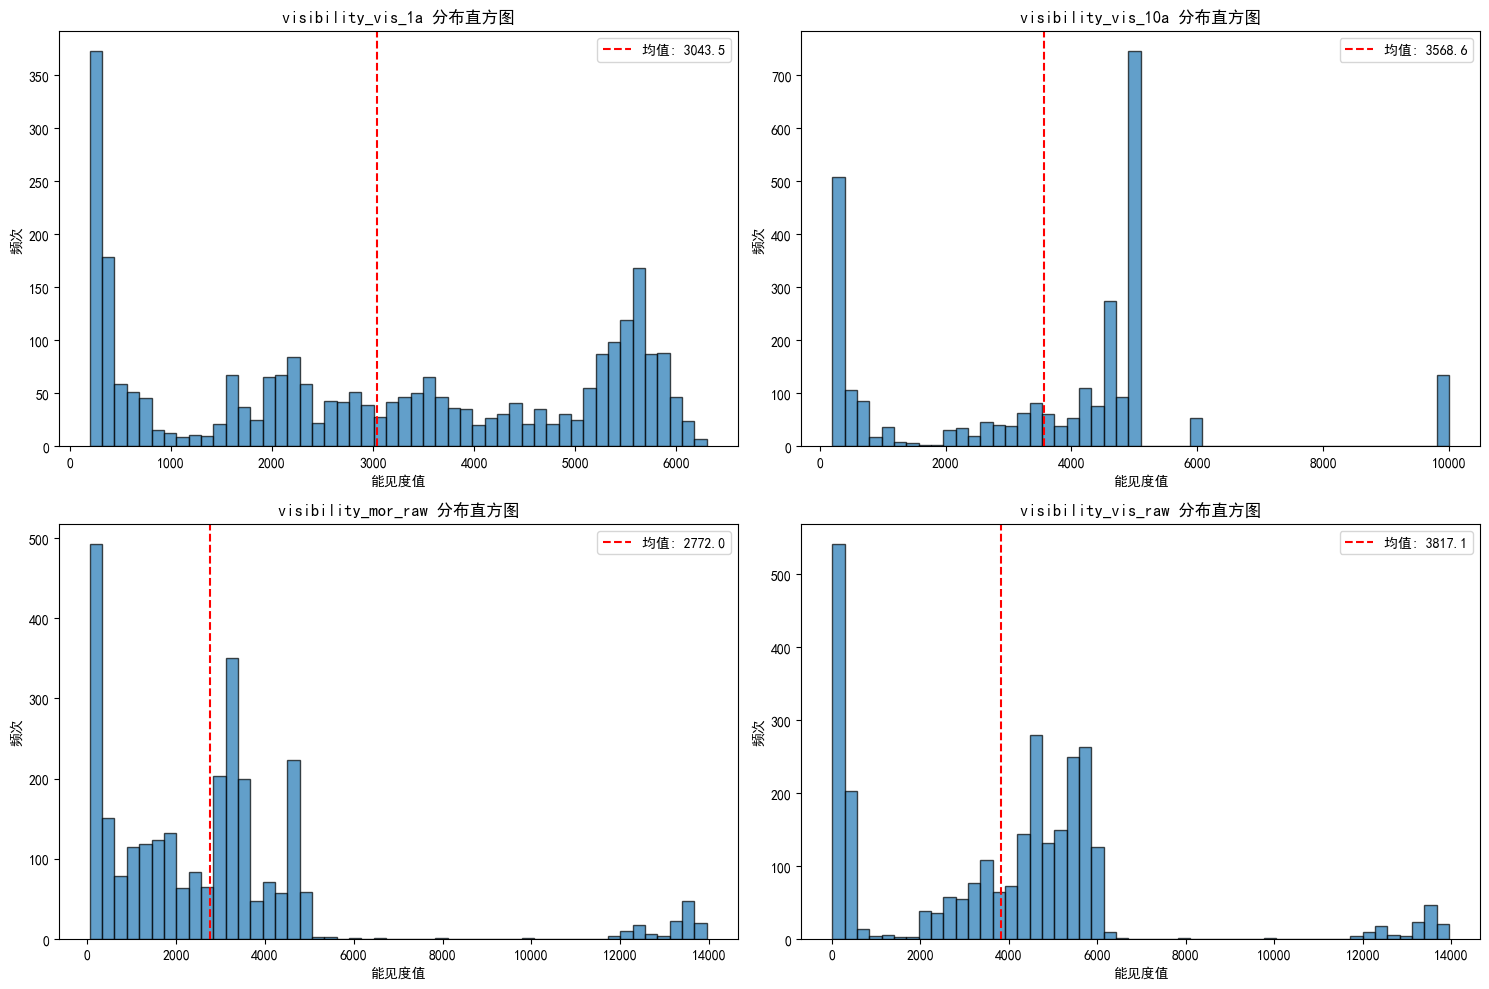


图像特征与主要能见度指标相关性分析
图像特征与visibility_mor_raw的相关系数:
laplacian_var       : -0.4189
sobel_mean          : -0.4100
sobel_std           : -0.3593
contrast_std        : -0.3942
high_freq_ratio     : -0.4243
edge_density        : -0.4118
entropy             : -0.1481
local_var_mean      : -0.4081
brenner             : -0.3663

相关系数排序（绝对值）:
high_freq_ratio     : -0.4243
laplacian_var       : -0.4189
edge_density        : -0.4118
sobel_mean          : -0.4100
local_var_mean      : -0.4081
contrast_std        : -0.3942
brenner             : -0.3663
sobel_std           : -0.3593
entropy             : -0.1481

气象要素与能见度相关性分析
气象要素与visibility_mor_raw的相关系数:
weather_temperature_c    :  0.8660
weather_humidity_pct     : -0.8787
weather_dewpoint_c       : -0.2921
weather_pressure_hpa     : -0.7477
weather_qnh_hpa          : -0.7477
wind_wind_speed_2m       :  0.4323
wind_wind_speed_10m      :  0.5016
wind_gust_speed          :  0.0557

气象要素相关系数排序（绝对值）:
weather_humidity_pct     : -0.8787
weather_temperature

In [2]:
# 第二步：目标变量分析和特征相关性分析

print("=" * 60)
print("目标变量（能见度指标）分析")
print("=" * 60)

# 分析4个能见度指标
visibility_cols = ['visibility_vis_1a', 'visibility_vis_10a', 'visibility_mor_raw', 'visibility_vis_raw']

print("能见度指标描述性统计:")
print(df[visibility_cols].describe())

print("\n能见度指标之间的相关性:")
vis_corr = df[visibility_cols].corr()
print(vis_corr)

# 绘制能见度指标分布图
plt.figure(figsize=(15, 10))
for i, col in enumerate(visibility_cols, 1):
    plt.subplot(2, 2, i)
    plt.hist(df[col], bins=50, alpha=0.7, edgecolor='black')
    plt.title(f'{col} 分布直方图')
    plt.xlabel('能见度值')
    plt.ylabel('频次')
    
    # 添加统计信息
    mean_val = df[col].mean()
    std_val = df[col].std()
    plt.axvline(mean_val, color='red', linestyle='--', label=f'均值: {mean_val:.1f}')
    plt.legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("图像特征与主要能见度指标相关性分析")
print("=" * 60)

# 选择图像特征
image_features = ['laplacian_var', 'sobel_mean', 'sobel_std', 'contrast_std', 
                 'high_freq_ratio', 'edge_density', 'entropy', 'local_var_mean', 'brenner']

# 选择visibility_mor_raw作为主要目标变量（这是标准的气象光学视程）
target = 'visibility_mor_raw'

print(f"图像特征与{target}的相关系数:")
correlations = {}
for feature in image_features:
    corr_coef = df[feature].corr(df[target])
    correlations[feature] = corr_coef
    print(f"{feature:<20}: {corr_coef:7.4f}")

print("\n相关系数排序（绝对值）:")
sorted_corr = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)
for feature, corr in sorted_corr:
    print(f"{feature:<20}: {corr:7.4f}")

print("\n" + "=" * 60)
print("气象要素与能见度相关性分析")
print("=" * 60)

# 选择气象特征
weather_features = ['weather_temperature_c', 'weather_humidity_pct', 'weather_dewpoint_c',
                   'weather_pressure_hpa', 'weather_qnh_hpa',
                   'wind_wind_speed_2m', 'wind_wind_speed_10m', 'wind_gust_speed']

print(f"气象要素与{target}的相关系数:")
weather_correlations = {}
for feature in weather_features:
    corr_coef = df[feature].corr(df[target])
    weather_correlations[feature] = corr_coef
    print(f"{feature:<25}: {corr_coef:7.4f}")

print("\n气象要素相关系数排序（绝对值）:")
sorted_weather_corr = sorted(weather_correlations.items(), key=lambda x: abs(x[1]), reverse=True)
for feature, corr in sorted_weather_corr:
    print(f"{feature:<25}: {corr:7.4f}")

# 检查极端值
print("\n" + "=" * 60)
print("异常值检查")
print("=" * 60)

print(f"{target}的极值情况:")
print(f"最小值: {df[target].min():.2f}")
print(f"最大值: {df[target].max():.2f}")
print(f"均值: {df[target].mean():.2f}")
print(f"中位数: {df[target].median():.2f}")

# 检查异常低的能见度值（可能的大雾情况）
low_vis_threshold = df[target].quantile(0.1)  # 10分位数
high_vis_threshold = df[target].quantile(0.9)  # 90分位数

print(f"\n能见度分布情况:")
print(f"10分位数 (低能见度): {low_vis_threshold:.2f}")
print(f"90分位数 (高能见度): {high_vis_threshold:.2f}")

low_vis_count = len(df[df[target] <= low_vis_threshold])
high_vis_count = len(df[df[target] >= high_vis_threshold])

print(f"低能见度样本数 (<= {low_vis_threshold:.2f}): {low_vis_count}")
print(f"高能见度样本数 (>= {high_vis_threshold:.2f}): {high_vis_count}")

In [4]:
# 第三步：特征选择和数据预处理

print("=" * 60)
print("特征选择和数据预处理")
print("=" * 60)

# 基于相关性分析选择特征
# 选择相关性较强的图像特征（|相关系数| > 0.35）
selected_image_features = ['high_freq_ratio', 'laplacian_var', 'edge_density', 
                          'sobel_mean', 'local_var_mean', 'contrast_std', 'brenner', 'sobel_std']

# 选择重要的气象特征
selected_weather_features = ['weather_humidity_pct', 'weather_temperature_c', 
                           'weather_pressure_hpa', 'wind_wind_speed_10m', 'wind_wind_speed_2m']

# 目标变量
target = 'visibility_mor_raw'

# 组合所有选择的特征
all_features = selected_image_features + selected_weather_features

print("选择的特征:")
print("图像特征:", selected_image_features)
print("气象特征:", selected_weather_features)
print("目标变量:", target)
print("总特征数:", len(all_features))

# 创建建模数据集
X = df[all_features].copy()
y = df[target].copy()

print(f"\n建模数据集形状:")
print(f"特征矩阵 X: {X.shape}")
print(f"目标变量 y: {y.shape}")

# 检查多重共线性
print("\n" + "=" * 60)
print("特征间相关性检查（检查多重共线性）")
print("=" * 60)

feature_corr = X.corr()
print("特征相关系数矩阵:")
print(feature_corr.round(3))

# 找出高相关的特征对
high_corr_pairs = []
for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        corr_val = abs(feature_corr.iloc[i, j])
        if corr_val > 0.8:  # 相关系数绝对值大于0.8认为存在多重共线性
            high_corr_pairs.append((feature_corr.columns[i], feature_corr.columns[j], corr_val))

print(f"\n高相关特征对 (|相关系数| > 0.8):")
if high_corr_pairs:
    for feat1, feat2, corr in high_corr_pairs:
        print(f"{feat1} - {feat2}: {corr:.3f}")
else:
    print("未发现严重的多重共线性问题")

# 数据标准化前的统计
print("\n" + "=" * 60)
print("数据标准化前的统计")
print("=" * 60)
print("特征的量纲差异:")
for feature in all_features:
    mean_val = X[feature].mean()
    std_val = X[feature].std()
    min_val = X[feature].min()
    max_val = X[feature].max()
    print(f"{feature:<25}: 均值={mean_val:10.2f}, 标准差={std_val:10.2f}, 范围=[{min_val:8.2f}, {max_val:10.2f}]")

# 数据标准化
print("\n进行数据标准化...")
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=all_features, index=X.index)

# 对目标变量进行对数变换（因为能见度数据通常呈偏态分布）
print("\n检查目标变量分布，考虑是否需要变换...")
y_stats = {
    '原始': y,
    'log变换': np.log(y + 1),  # 加1避免log(0)
    'sqrt变换': np.sqrt(y)
}

print("目标变量变换后的分布统计:")
for name, transformed_y in y_stats.items():
    skewness = stats.skew(transformed_y)
    kurtosis = stats.kurtosis(transformed_y)
    print(f"{name:<10}: 偏度={skewness:6.3f}, 峰度={kurtosis:6.3f}")

# 选择偏度最接近0的变换
best_transform = min(y_stats.items(), key=lambda x: abs(stats.skew(x[1])))
print(f"\n选择变换方式: {best_transform[0]} (偏度最接近0)")

if best_transform[0] == 'log变换':
    y_transformed = np.log(y + 1)
    transform_type = 'log'
elif best_transform[0] == 'sqrt变换':
    y_transformed = np.sqrt(y)
    transform_type = 'sqrt'
else:
    y_transformed = y
    transform_type = 'none'

print(f"使用的目标变量变换: {transform_type}")

# 数据分割
print("\n" + "=" * 60)
print("数据分割")
print("=" * 60)

# 分割数据集 (80%训练，20%测试)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_transformed, test_size=0.2, random_state=42, stratify=None
)

print(f"训练集大小: {X_train.shape[0]} 样本")
print(f"测试集大小: {X_test.shape[0]} 样本")
print(f"训练集目标变量范围: [{y_train.min():.2f}, {y_train.max():.2f}]")
print(f"测试集目标变量范围: [{y_test.min():.2f}, {y_test.max():.2f}]")

# 保存预处理信息，用于后续建模
preprocessing_info = {
    'selected_features': all_features,
    'image_features': selected_image_features,
    'weather_features': selected_weather_features,
    'target': target,
    'transform_type': transform_type,
    'scaler_X': scaler_X,
    'train_size': len(X_train),
    'test_size': len(X_test)
}

print(f"\n预处理完成，准备建模...")
print(f"特征标准化: 完成")
print(f"目标变量变换: {transform_type}")
print(f"数据分割: 完成")

特征选择和数据预处理
选择的特征:
图像特征: ['high_freq_ratio', 'laplacian_var', 'edge_density', 'sobel_mean', 'local_var_mean', 'contrast_std', 'brenner', 'sobel_std']
气象特征: ['weather_humidity_pct', 'weather_temperature_c', 'weather_pressure_hpa', 'wind_wind_speed_10m', 'wind_wind_speed_2m']
目标变量: visibility_mor_raw
总特征数: 13

建模数据集形状:
特征矩阵 X: (2774, 13)
目标变量 y: (2774,)

特征间相关性检查（检查多重共线性）
特征相关系数矩阵:
                       high_freq_ratio  laplacian_var  edge_density  \
high_freq_ratio                  1.000          0.884         0.875   
laplacian_var                    0.884          1.000         0.957   
edge_density                     0.875          0.957         1.000   
sobel_mean                       0.879          0.993         0.974   
local_var_mean                   0.880          1.000         0.956   
contrast_std                     0.826          0.958         0.882   
brenner                          0.869          0.996         0.944   
sobel_std                        0.878          0.

In [5]:
# 第四步：处理多重共线性并建立回归模型

from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

print("=" * 70)
print("多重共线性处理和特征选择")
print("=" * 70)

# 方法1：基于VIF (方差膨胀因子) 选择特征
def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["特征"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]
    return vif_data.sort_values('VIF', ascending=False)

print("计算方差膨胀因子(VIF):")
vif_scores = calculate_vif(X_train)
print(vif_scores)
print("\n注：VIF > 10 表示存在严重多重共线性")

# 方法2：基于相关性手动选择代表性特征
print("\n" + "=" * 70)
print("手动选择代表性特征（避免高相关性）")
print("=" * 70)

# 基于相关性分析，从每组高相关特征中选择一个代表
selected_features_manual = [
    'laplacian_var',        # 代表图像清晰度组 (与local_var_mean完全相关，选一个)
    'high_freq_ratio',      # 高频信息比例（相对独立）
    'edge_density',         # 边缘密度（代表边缘特征组）
    'contrast_std',         # 对比度标准差
    'weather_humidity_pct', # 湿度（气象要素中最重要）
    'weather_temperature_c',# 温度（与湿度高相关但物理意义不同）
    'wind_wind_speed_10m'   # 风速（相对独立的气象要素）
]

print("手动选择的特征:")
for i, feat in enumerate(selected_features_manual, 1):
    print(f"{i}. {feat}")

# 检查手动选择特征间的相关性
X_manual = X_train[selected_features_manual]
manual_corr = X_manual.corr()
print(f"\n手动选择特征间的相关性矩阵:")
print(manual_corr.round(3))

# 计算手动选择特征的VIF
vif_manual = calculate_vif(X_manual)
print(f"\n手动选择特征的VIF:")
print(vif_manual)

print("\n" + "=" * 70)
print("建立多种回归模型")
print("=" * 70)

# 使用手动选择的特征建立多种模型
X_train_selected = X_train[selected_features_manual]
X_test_selected = X_test[selected_features_manual]

models = {
    '普通线性回归': LinearRegression(),
    '岭回归(Ridge)': Ridge(alpha=1.0),
    'Lasso回归': Lasso(alpha=0.1),
    '弹性网络': ElasticNet(alpha=0.1, l1_ratio=0.5)
}

# 训练和评估模型
model_results = {}
for name, model in models.items():
    print(f"\n{'='*20} {name} {'='*20}")
    
    # 训练模型
    model.fit(X_train_selected, y_train)
    
    # 预测
    y_train_pred = model.predict(X_train_selected)
    y_test_pred = model.predict(X_test_selected)
    
    # 评估指标
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    print(f"训练集 R²: {train_r2:.4f}")
    print(f"测试集 R²: {test_r2:.4f}")
    print(f"训练集 RMSE: {train_rmse:.4f}")
    print(f"测试集 RMSE: {test_rmse:.4f}")
    print(f"训练集 MAE: {train_mae:.4f}")
    print(f"测试集 MAE: {test_mae:.4f}")
    
    # 保存结果
    model_results[name] = {
        'model': model,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'coefficients': getattr(model, 'coef_', None),
        'intercept': getattr(model, 'intercept_', None)
    }

# 选择最佳模型（基于测试集R²）
best_model_name = max(model_results.keys(), key=lambda k: model_results[k]['test_r2'])
best_model = model_results[best_model_name]

print(f"\n" + "=" * 70)
print("最佳模型和数学公式")
print("=" * 70)

print(f"最佳模型: {best_model_name}")
print(f"测试集 R²: {best_model['test_r2']:.4f}")
print(f"测试集 RMSE: {best_model['test_rmse']:.4f}")

# 建立明确的数学公式
print(f"\n数学模型公式:")
print("=" * 50)

if best_model['coefficients'] is not None:
    print("标准化后的特征回归方程:")
    print("sqrt(能见度) = β₀ + β₁×X₁ + β₂×X₂ + ... + β₇×X₇")
    print()
    print("其中:")
    print(f"β₀ (截距) = {best_model['intercept']:.6f}")
    
    for i, (feat, coef) in enumerate(zip(selected_features_manual, best_model['coefficients']), 1):
        print(f"β{i} ({feat}) = {coef:8.6f}")
    
    print(f"\n完整公式:")
    formula_parts = [f"{best_model['intercept']:.6f}"]
    for feat, coef in zip(selected_features_manual, best_model['coefficients']):
        sign = "+" if coef >= 0 else ""
        formula_parts.append(f"{sign}{coef:.6f}×{feat}")
    
    print("sqrt(visibility_mor_raw) = " + " ".join(formula_parts))
    
    print(f"\n因此，能见度预测公式为:")
    print("visibility_mor_raw = [上述公式结果]²")

# 特征重要性分析
print(f"\n" + "=" * 70)
print("特征重要性分析")
print("=" * 70)

if best_model['coefficients'] is not None:
    # 计算标准化系数的绝对值作为重要性指标
    feature_importance = pd.DataFrame({
        '特征': selected_features_manual,
        '回归系数': best_model['coefficients'],
        '重要性(|系数|)': np.abs(best_model['coefficients'])
    }).sort_values('重要性(|系数|)', ascending=False)
    
    print("特征重要性排序:")
    print(feature_importance)
    
    # 分析系数符号的物理意义
    print(f"\n系数符号的物理意义:")
    for feat, coef in zip(selected_features_manual, best_model['coefficients']):
        direction = "正相关" if coef > 0 else "负相关"
        print(f"{feat:<25}: {coef:8.6f} ({direction})")

多重共线性处理和特征选择
计算方差膨胀因子(VIF):
                       特征          VIF
4          local_var_mean  6136.825949
1           laplacian_var  2411.937043
6                 brenner   686.834742
7               sobel_std   385.560343
3              sobel_mean   207.099755
2            edge_density    55.304099
9   weather_temperature_c    32.213460
5            contrast_std    23.815949
8    weather_humidity_pct    19.438271
10   weather_pressure_hpa    12.540789
11    wind_wind_speed_10m    11.098560
0         high_freq_ratio     9.209758
12     wind_wind_speed_2m     7.895214

注：VIF > 10 表示存在严重多重共线性

手动选择代表性特征（避免高相关性）
手动选择的特征:
1. laplacian_var
2. high_freq_ratio
3. edge_density
4. contrast_std
5. weather_humidity_pct
6. weather_temperature_c
7. wind_wind_speed_10m

手动选择特征间的相关性矩阵:
                       laplacian_var  high_freq_ratio  edge_density  \
laplacian_var                  1.000            0.871         0.957   
high_freq_ratio                0.871            1.000         0.860   
edge_

模型验证和残差分析
Lasso回归选择的有效特征:
laplacian_var            :  -1.322917
high_freq_ratio          :  -0.804692
weather_humidity_pct     :  -1.347841
weather_temperature_c    :  24.243342
wind_wind_speed_10m      :  -4.299586

最终简化模型性能:
训练集 R²: 0.9170
测试集 R²: 0.9160
测试集 RMSE: 7.0581 (标准化sqrt尺度)
测试集 MAE: 5.4116 (标准化sqrt尺度)

最终数学公式（标准化特征）
标准化特征的回归方程:
sqrt(visibility_mor_raw) = β₀ + Σ(βᵢ × Xᵢ_standardized)

其中：
β₀ (截距) = 46.406014
β1 (laplacian_var) =  -1.366408
β2 (high_freq_ratio) =  -0.886165
β3 (weather_humidity_pct) =  -1.690709
β4 (weather_temperature_c) =  24.235712
β5 (wind_wind_speed_10m) =  -4.686833

完整标准化公式:
sqrt(visibility_mor_raw) = 46.406014 -1.366408×laplacian_var_std -0.886165×high_freq_ratio_std -1.690709×weather_humidity_pct_std +24.235712×weather_temperature_c_std -4.686833×wind_wind_speed_10m_std

转换为原始特征尺度的公式
laplacian_var:
  均值 = 275.972625
  标准差 = 153.518867
high_freq_ratio:
  均值 = 0.448237
  标准差 = 0.012723
weather_humidity_pct:
  均值 = 88.696828
  标准差 = 15.989002
weather_tem

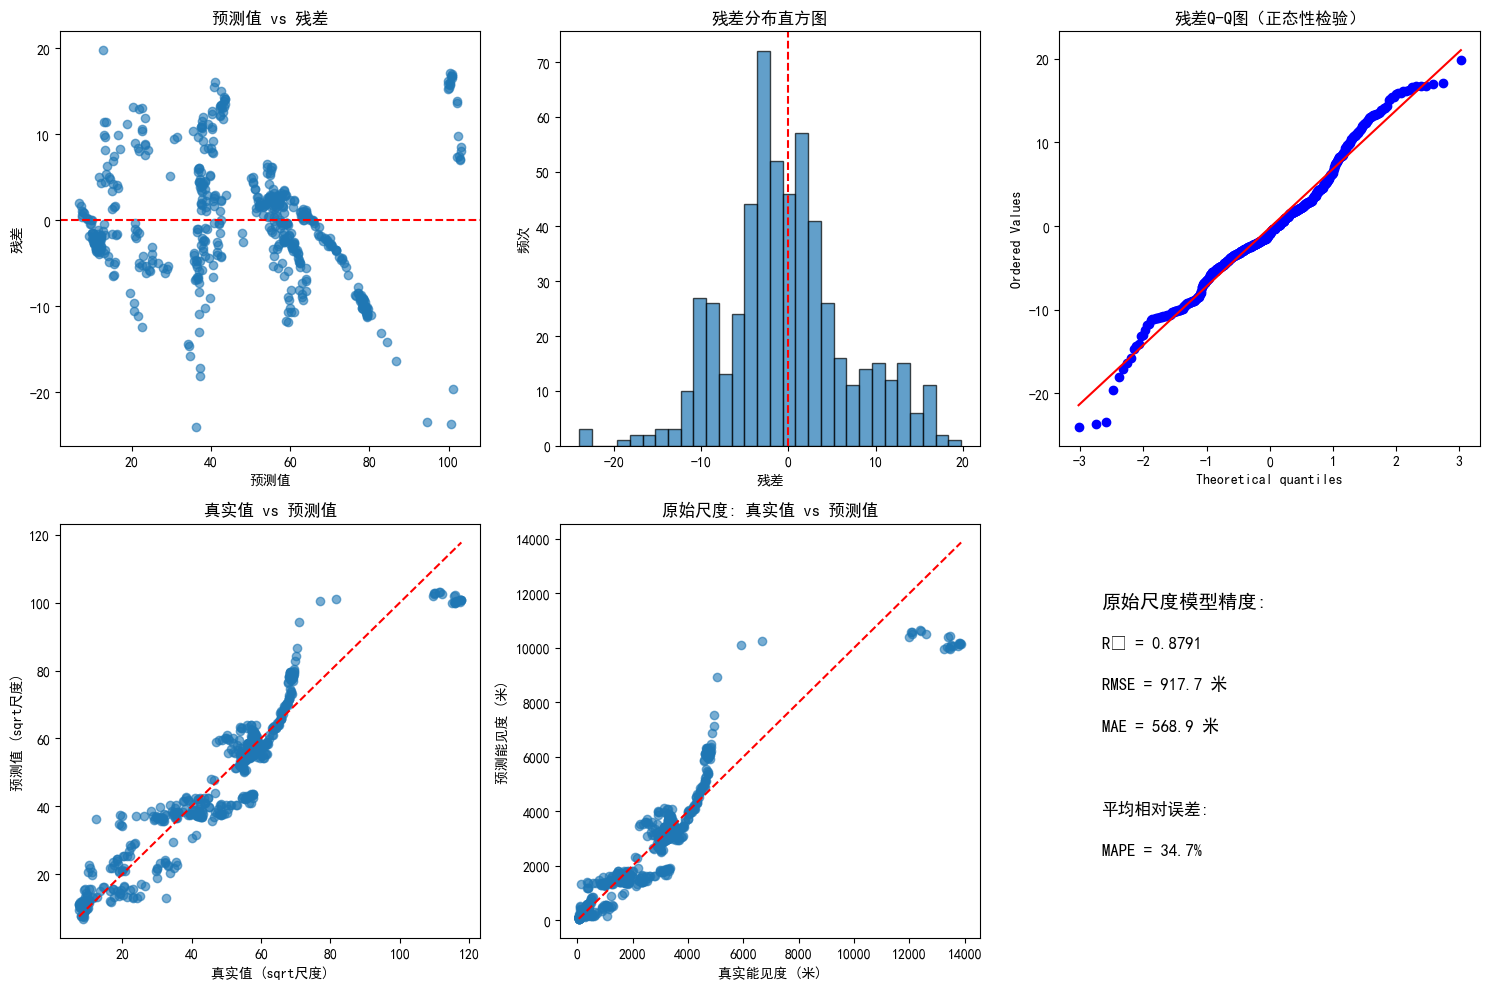


原始尺度（米）的模型精度:
R² = 0.8791
RMSE = 917.7 米
MAE = 568.9 米
MAPE = 34.7%

模型总结
1. 最终选择的特征数量: 5
2. 模型类型: 多元线性回归 (经Lasso特征选择)
3. 目标变量变换: 平方根变换
4. 特征标准化: Z-score标准化
5. 模型精度: R² = 0.8791, RMSE = 917.7米
6. 平均绝对百分比误差: 34.7%


In [6]:
# 第五步：模型验证、残差分析和最终公式

print("=" * 70)
print("模型验证和残差分析")
print("=" * 70)

# 获取最佳模型（Lasso回归）
best_model = model_results['Lasso回归']['model']

# 获取有效特征（系数不为0的特征）
active_features = []
active_coefficients = []
for feat, coef in zip(selected_features_manual, best_model.coef_):
    if abs(coef) > 1e-10:  # 系数不为0
        active_features.append(feat)
        active_coefficients.append(coef)

print("Lasso回归选择的有效特征:")
for feat, coef in zip(active_features, active_coefficients):
    print(f"{feat:<25}: {coef:10.6f}")

# 重新训练只使用有效特征的简化模型
X_train_final = X_train[active_features]
X_test_final = X_test[active_features]

final_model = LinearRegression()
final_model.fit(X_train_final, y_train)

# 预测
y_train_pred_final = final_model.predict(X_train_final)
y_test_pred_final = final_model.predict(X_test_final)

# 最终模型性能
final_train_r2 = r2_score(y_train, y_train_pred_final)
final_test_r2 = r2_score(y_test, y_test_pred_final)
final_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_final))
final_test_mae = mean_absolute_error(y_test, y_test_pred_final)

print(f"\n最终简化模型性能:")
print(f"训练集 R²: {final_train_r2:.4f}")
print(f"测试集 R²: {final_test_r2:.4f}")
print(f"测试集 RMSE: {final_test_rmse:.4f} (标准化sqrt尺度)")
print(f"测试集 MAE: {final_test_mae:.4f} (标准化sqrt尺度)")

print("\n" + "=" * 70)
print("最终数学公式（标准化特征）")
print("=" * 70)

print("标准化特征的回归方程:")
print("sqrt(visibility_mor_raw) = β₀ + Σ(βᵢ × Xᵢ_standardized)")
print()
print("其中：")
print(f"β₀ (截距) = {final_model.intercept_:.6f}")

formula_parts = [f"{final_model.intercept_:.6f}"]
for i, (feat, coef) in enumerate(zip(active_features, final_model.coef_), 1):
    print(f"β{i} ({feat}) = {coef:10.6f}")
    sign = "+" if coef >= 0 else ""
    formula_parts.append(f"{sign}{coef:.6f}×{feat}_std")

print(f"\n完整标准化公式:")
print("sqrt(visibility_mor_raw) = " + " ".join(formula_parts))

print("\n" + "=" * 70)
print("转换为原始特征尺度的公式")
print("=" * 70)

# 获取标准化参数
feature_means = []
feature_stds = []
for feat in active_features:
    idx = list(X.columns).index(feat)
    mean_val = scaler_X.mean_[idx]
    std_val = scaler_X.scale_[idx]
    feature_means.append(mean_val)
    feature_stds.append(std_val)
    print(f"{feat}:")
    print(f"  均值 = {mean_val:.6f}")
    print(f"  标准差 = {std_val:.6f}")

# 计算原始尺度的系数和截距
original_intercept = final_model.intercept_
for coef, mean_val, std_val in zip(final_model.coef_, feature_means, feature_stds):
    original_intercept -= coef * mean_val / std_val

original_coefficients = []
for coef, std_val in zip(final_model.coef_, feature_stds):
    original_coefficients.append(coef / std_val)

print(f"\n原始尺度的回归方程:")
print("sqrt(visibility_mor_raw) = α₀ + Σ(αᵢ × Xᵢ_original)")
print()
print("其中：")
print(f"α₀ (截距) = {original_intercept:.6f}")

original_formula_parts = [f"{original_intercept:.6f}"]
for i, (feat, coef) in enumerate(zip(active_features, original_coefficients), 1):
    print(f"α{i} ({feat}) = {coef:.10f}")
    sign = "+" if coef >= 0 else ""
    original_formula_parts.append(f"{sign}{coef:.6e}×{feat}")

print(f"\n完整原始尺度公式:")
print("sqrt(visibility_mor_raw) = " + " ".join(original_formula_parts))

print(f"\n最终能见度预测公式:")
print("visibility_mor_raw = [上述sqrt结果]²")

print("\n" + "=" * 70)
print("残差分析")
print("=" * 70)

# 残差分析
residuals_train = y_train - y_train_pred_final
residuals_test = y_test - y_test_pred_final

print("残差统计:")
print(f"训练集残差 - 均值: {residuals_train.mean():.6f}, 标准差: {residuals_train.std():.6f}")
print(f"测试集残差 - 均值: {residuals_test.mean():.6f}, 标准差: {residuals_test.std():.6f}")

# 绘制残差图
plt.figure(figsize=(15, 10))

# 预测值vs残差图
plt.subplot(2, 3, 1)
plt.scatter(y_test_pred_final, residuals_test, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('预测值')
plt.ylabel('残差')
plt.title('预测值 vs 残差')

# 残差直方图
plt.subplot(2, 3, 2)
plt.hist(residuals_test, bins=30, alpha=0.7, edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('残差')
plt.ylabel('频次')
plt.title('残差分布直方图')

# Q-Q图（正态性检验）
from scipy import stats
plt.subplot(2, 3, 3)
stats.probplot(residuals_test, dist="norm", plot=plt)
plt.title('残差Q-Q图（正态性检验）')

# 真实值vs预测值图
plt.subplot(2, 3, 4)
plt.scatter(y_test, y_test_pred_final, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'red', linestyle='--')
plt.xlabel('真实值 (sqrt尺度)')
plt.ylabel('预测值 (sqrt尺度)')
plt.title('真实值 vs 预测值')

# 转换回原始尺度进行比较
y_test_original = y_test**2  # sqrt逆变换
y_test_pred_original = y_test_pred_final**2

plt.subplot(2, 3, 5)
plt.scatter(y_test_original, y_test_pred_original, alpha=0.6)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 'red', linestyle='--')
plt.xlabel('真实能见度 (米)')
plt.ylabel('预测能见度 (米)')
plt.title('原始尺度: 真实值 vs 预测值')

# 计算原始尺度的精度
original_r2 = r2_score(y_test_original, y_test_pred_original)
original_rmse = np.sqrt(mean_squared_error(y_test_original, y_test_pred_original))
original_mae = mean_absolute_error(y_test_original, y_test_pred_original)

plt.subplot(2, 3, 6)
plt.text(0.1, 0.8, f'原始尺度模型精度:', fontsize=14, fontweight='bold')
plt.text(0.1, 0.7, f'R² = {original_r2:.4f}', fontsize=12)
plt.text(0.1, 0.6, f'RMSE = {original_rmse:.1f} 米', fontsize=12)
plt.text(0.1, 0.5, f'MAE = {original_mae:.1f} 米', fontsize=12)
plt.text(0.1, 0.3, f'平均相对误差:', fontsize=12)
mape = np.mean(np.abs((y_test_original - y_test_pred_original) / y_test_original)) * 100
plt.text(0.1, 0.2, f'MAPE = {mape:.1f}%', fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"\n原始尺度（米）的模型精度:")
print(f"R² = {original_r2:.4f}")
print(f"RMSE = {original_rmse:.1f} 米")
print(f"MAE = {original_mae:.1f} 米")
print(f"MAPE = {mape:.1f}%")

print("\n" + "=" * 70)
print("模型总结")
print("=" * 70)

print("1. 最终选择的特征数量:", len(active_features))
print("2. 模型类型: 多元线性回归 (经Lasso特征选择)")
print("3. 目标变量变换: 平方根变换")
print("4. 特征标准化: Z-score标准化")
print(f"5. 模型精度: R² = {original_r2:.4f}, RMSE = {original_rmse:.1f}米")
print(f"6. 平均绝对百分比误差: {mape:.1f}%")